# Multi-Element DG Advection: h-Refinement Convergence on Square PBC Domain

This notebook is a brand new implementation for h-refinement convergence on a square physical domain with fully periodic boundary exchange.

## Core Design Choices

- Physical domain is $[0,1] \times [0,1]$, triangulated from a structured square grid.
- Periodic boundary mapping is enforced by coordinate-based overwrite of `vmapP` after standard connectivity mapping.
- No boundary ODE system and no exact-stage boundary injection are used.
- Surface lifting uses a projected inverse mass matrix (`M_inv_projected`) to preserve high-order behavior on simplex elements.

## PDE Setup

$$\frac{\partial q}{\partial t} + \mathbf{V}\cdot\nabla q = 0, \quad \mathbf{V}=(1,1).$$

Exact periodic solution:
$$q_{\text{exact}}(x,y,t)=\sin\left(2\pi(x+y-2t)\right).$$

In [7]:
# ============================================================================
# CELL 1: Imports and Global Configuration
# ============================================================================

from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display


def resolve_project_root() -> Path:
    """Resolve project root robustly for notebook execution contexts.

    Returns:
        Absolute path to the repository root containing src/.
    """
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists():
        return cwd
    if cwd.name == "experimental" and (cwd.parents[1] / "src").exists():
        return cwd.parents[1]
    for parent in cwd.parents:
        if (parent / "src").exists():
            return parent
    raise FileNotFoundError("Cannot locate project root containing src/.")


project_root = resolve_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.core.generators import get_reference_data
from src.core.connectivity import build_connectivity
from src.geometry.metrics import compute_geometric_factors_batch
from src.geometry.mappings import rs_to_xy
from src.bases.vandermonde import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
from src.reconstruction import build_differentiation_matrices, build_fmask_table1

# Discretization / integration settings
k = 4
N = k + 1
CFL = 1.0
flux_type = "upwind"  # choices: upwind, central, LF
alpha_lf = 1.0

# Reference simplex data
ref_data = get_reference_data("table1", k)
xi_ref = ref_data["xi"]
eta_ref = ref_data["eta"]
weights_ref = ref_data["weights"]
weights_1d = ref_data["weights_1d"]
Np = int(len(xi_ref))

# Exact periodic solution and velocity field
x, y, t = sp.symbols("x y t")
q_expr = sp.sin(2 * np.pi * (x + y - 2 * t))
u_expr = sp.sympify(1)
v_expr = sp.sympify(1)

q_exact_func = sp.lambdify((x, y, t), q_expr, "numpy")
u_func_raw = sp.lambdify((x, y, t), u_expr, "numpy")
v_func_raw = sp.lambdify((x, y, t), v_expr, "numpy")

print(f"Project root: {project_root}")
print(f"k={k}, Np={Np}, nfp={len(weights_1d)}, CFL={CFL}")
print(f"Exact solution: {q_expr}")

Project root: /Users/user/code/Simplex-DG-solver
k=4, Np=22, nfp=5, CFL=1.0
Exact solution: sin(-12.5663706143592*t + 6.28318530717959*x + 6.28318530717959*y)


In [8]:
# ============================================================================
# CELL 2: Square Mesh and Periodic Topology Mapping
# ============================================================================


def generate_square_mesh(n_div: int) -> tuple[np.ndarray, np.ndarray, int]:
    """Generate a uniform triangular mesh on [0,1]x[0,1].

    Each Cartesian cell is split into two triangles with CCW orientation.

    Args:
        n_div: Number of subdivisions in x and y directions.

    Returns:
        nodes: Vertex coordinates, shape (N_vertices, 2).
        EToV: Element-to-vertex connectivity, shape (K, 3).
        K: Number of triangles, equal to 2*n_div^2.
    """
    if n_div < 1:
        raise ValueError(f"n_div must be >= 1, got {n_div}")

    grid = np.linspace(0.0, 1.0, n_div + 1)
    Xg, Yg = np.meshgrid(grid, grid, indexing="xy")
    nodes = np.column_stack((Xg.ravel(), Yg.ravel()))

    def node_id(i: int, j: int) -> int:
        return j * (n_div + 1) + i

    triangles: list[list[int]] = []
    for j in range(n_div):
        for i in range(n_div):
            v00 = node_id(i, j)
            v10 = node_id(i + 1, j)
            v01 = node_id(i, j + 1)
            v11 = node_id(i + 1, j + 1)

            triangles.append([v00, v10, v11])
            triangles.append([v00, v11, v01])

    EToV = np.asarray(triangles, dtype=int)
    K = int(EToV.shape[0])

    # Signed area check for strict CCW orientation.
    tri_nodes = nodes[EToV]
    signed_area = 0.5 * (
        (tri_nodes[:, 1, 0] - tri_nodes[:, 0, 0]) * (tri_nodes[:, 2, 1] - tri_nodes[:, 0, 1])
        - (tri_nodes[:, 2, 0] - tri_nodes[:, 0, 0]) * (tri_nodes[:, 1, 1] - tri_nodes[:, 0, 1])
    )
    if np.any(signed_area <= 0.0):
        bad = np.where(signed_area <= 0.0)[0]
        raise ValueError(f"Found non-CCW elements: {bad[:10]}")

    return nodes, EToV, K


def build_global_index_maps(
    EToV: np.ndarray,
    EToE: np.ndarray,
    EToF: np.ndarray,
    xi_ref: np.ndarray,
    eta_ref: np.ndarray,
    Np: int,
    weights_1d: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Build standard DG trace maps before periodic overwrite.

    Args:
        EToV, EToE, EToF: Mesh and face connectivity.
        xi_ref, eta_ref: Reference nodal coordinates.
        Np: Number of volume nodes per element.
        weights_1d: 1D face quadrature weights.

    Returns:
        vmapM: Interior node map, shape (3*nfp, K).
        vmapP: Exterior node map (standard), shape (3*nfp, K).
        boundary_mask: Boolean mask where vmapM equals vmapP.
        fmask: Local face-node mapping, shape (nfp, 3).
    """
    K = int(EToV.shape[0])
    nfp = int(len(weights_1d))

    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2.0,
        (xi_ref + 1.0) / 2.0,
        (eta_ref + 1.0) / 2.0,
    ])
    fmask = build_fmask_table1(bary_coords)

    vmapM = np.zeros((3 * nfp, K), dtype=int)
    vmapP = np.zeros((3 * nfp, K), dtype=int)

    for k_elem in range(K):
        for face in range(3):
            local_nodes = fmask[:, face]
            interior = k_elem * Np + local_nodes
            vmapM[face * nfp:(face + 1) * nfp, k_elem] = interior

            k_neighbor = int(EToE[k_elem, face])
            f_neighbor = int(EToF[k_elem, face])
            if k_neighbor == k_elem:
                vmapP[face * nfp:(face + 1) * nfp, k_elem] = interior
            else:
                neighbor_nodes = fmask[:, f_neighbor]
                ext = k_neighbor * Np + neighbor_nodes
                vmapP[face * nfp:(face + 1) * nfp, k_elem] = ext[::-1]

    boundary_mask = vmapM == vmapP
    return vmapM, vmapP, boundary_mask, fmask


def _coord_key(x_val: float, y_val: float, tol: float) -> tuple[int, int]:
    """Convert coordinates to quantized integer keys for robust hash lookup."""
    return (int(np.round(x_val / tol)), int(np.round(y_val / tol)))


def apply_periodic_vmapP(
    vmapM: np.ndarray,
    vmapP: np.ndarray,
    boundary_mask: np.ndarray,
    X: np.ndarray,
    Y: np.ndarray,
    tol: float = 1e-12,
) -> np.ndarray:
    """Overwrite boundary trace map with periodic counterparts based on coordinates.

    Mapping rules on [0,1]^2:
    - x=0 maps to x=1 (same y), and x=1 maps to x=0
    - y=0 maps to y=1 (same x), and y=1 maps to y=0

    Args:
        vmapM: Interior trace map, shape (3*nfp, K).
        vmapP: Exterior trace map before periodic overwrite.
        boundary_mask: Boolean mask marking boundary trace slots.
        X, Y: Physical coordinates for all nodal unknowns, shape (Np, K).
        tol: Coordinate matching tolerance.

    Returns:
        Periodic-overwritten exterior trace map.
    """
    vmapP_periodic = vmapP.copy()

    x_flat = X.flatten(order="F")
    y_flat = Y.flatten(order="F")

    # Extract boundary coordinates as required by the periodic post-processing step.
    X_bc = x_flat[vmapM[boundary_mask]]
    Y_bc = y_flat[vmapM[boundary_mask]]
    print(f"Boundary trace nodes detected: {X_bc.size}")

    # Build coordinate lookup over all DG nodal unknowns.
    coord_lookup: dict[tuple[int, int], list[int]] = {}
    for gid in range(x_flat.size):
        key = _coord_key(float(x_flat[gid]), float(y_flat[gid]), tol)
        coord_lookup.setdefault(key, []).append(gid)

    boundary_slots = np.argwhere(boundary_mask)
    replaced = 0

    for slot_row, slot_col in boundary_slots:
        gid_m = int(vmapM[slot_row, slot_col])
        x_m = float(x_flat[gid_m])
        y_m = float(y_flat[gid_m])

        x_target = x_m
        y_target = y_m

        if np.isclose(x_m, 0.0, atol=tol):
            x_target = 1.0
        elif np.isclose(x_m, 1.0, atol=tol):
            x_target = 0.0

        if np.isclose(y_m, 0.0, atol=tol):
            y_target = 1.0
        elif np.isclose(y_m, 1.0, atol=tol):
            y_target = 0.0

        key_target = _coord_key(x_target, y_target, tol)
        candidates = coord_lookup.get(key_target, [])
        if not candidates:
            raise ValueError(
                f"No periodic counterpart for (x={x_m:.16e}, y={y_m:.16e}) "
                f"targeting (x={x_target:.16e}, y={y_target:.16e})."
            )

        gid_p = next((cand for cand in candidates if cand != gid_m), candidates[0])
        vmapP_periodic[slot_row, slot_col] = gid_p
        replaced += 1

    remaining_self_maps = int(np.sum(vmapM == vmapP_periodic))
    print(f"Periodic overwrite complete: replaced={replaced}, remaining self-maps={remaining_self_maps}")
    return vmapP_periodic

In [9]:
# ============================================================================
# CELL 3: DG Operators and RHS (Projected Mass Inverse, No Boundary Injection)
# ============================================================================


def compute_metrics_vectorized(
    nodes: np.ndarray, EToV: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute elementwise geometric factors and characteristic length scales.

    Args:
        nodes: Mesh vertex coordinates, shape (N_vertices, 2).
        EToV: Element-to-vertex connectivity, shape (K, 3).

    Returns:
        J, rx, ry, sx, sy: Geometric factors, each shape (K,).
        h_min: Minimum edge length per element, shape (K,).
    """
    vertices = nodes[EToV]  # (K, 3, 2)
    metrics = compute_geometric_factors_batch(vertices)

    e01 = np.linalg.norm(vertices[:, 1, :] - vertices[:, 0, :], axis=1)
    e12 = np.linalg.norm(vertices[:, 2, :] - vertices[:, 1, :], axis=1)
    e20 = np.linalg.norm(vertices[:, 0, :] - vertices[:, 2, :], axis=1)
    h_min = np.minimum(np.minimum(e01, e12), e20)

    return metrics["J"], metrics["rx"], metrics["ry"], metrics["sx"], metrics["sy"], h_min


def initialize_multi_element_dg(
    nodes: np.ndarray, EToV: np.ndarray, K: int
) -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray,
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """Initialize reference operators, geometric factors, and physical node coordinates.

    Args:
        nodes: Mesh vertices.
        EToV: Element-to-vertex connectivity.
        K: Number of elements.

    Returns:
        D_r_ref, D_s_ref, E, fmask, weights_ref, X, Y,
        J, rx, ry, sx, sy, h_min_array, M_inv_projected
    """
    nfp = int(len(weights_1d))

    V_nodal = vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    Vr, Vs = grad_vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    D_r_ref, D_s_ref = build_differentiation_matrices(V_nodal, Vr, Vs, w=weights_ref)

    W = np.diag(weights_ref)
    M_modal = V_nodal.T @ W @ V_nodal

    # Projected inverse mass operator used in surface lifting.
    M_inv_projected = V_nodal @ np.linalg.inv(M_modal) @ V_nodal.T

    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2.0,
        (xi_ref + 1.0) / 2.0,
        (eta_ref + 1.0) / 2.0,
    ])
    fmask = build_fmask_table1(bary_coords)

    E = np.zeros((3 * nfp, Np))
    for face in range(3):
        for local_i, node_idx in enumerate(fmask[:, face]):
            E[face * nfp + local_i, node_idx] = 1.0

    J, rx, ry, sx, sy, h_min_array = compute_metrics_vectorized(nodes, EToV)

    X = np.zeros((Np, K))
    Y = np.zeros((Np, K))
    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        x_phys, y_phys = rs_to_xy(xi_ref, eta_ref, v1, v2, v3)
        X[:, k_elem] = x_phys
        Y[:, k_elem] = y_phys

    return D_r_ref, D_s_ref, E, fmask, weights_ref, X, Y, J, rx, ry, sx, sy, h_min_array, M_inv_projected


def compute_face_geometry(
    nodes: np.ndarray, EToV: np.ndarray, weights_1d: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute face Jacobians and outward normals for each element face.

    Args:
        nodes: Mesh vertices.
        EToV: Element-to-vertex connectivity.
        weights_1d: 1D face quadrature weights.

    Returns:
        nx_expanded, ny_expanded, J_face_expanded, each shape (3*nfp, K).
    """
    K = int(EToV.shape[0])
    nfp = int(len(weights_1d))

    J_face = np.zeros((3, K))
    nx_array = np.zeros((3, K))
    ny_array = np.zeros((3, K))

    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        edges = [v2 - v1, v3 - v2, v1 - v3]
        for face in range(3):
            dx, dy = edges[face]
            length = np.hypot(dx, dy)
            J_face[face, k_elem] = length / 2.0
            nx_array[face, k_elem] = dy / length
            ny_array[face, k_elem] = -dx / length

    nx_expanded = np.repeat(nx_array, nfp, axis=0)
    ny_expanded = np.repeat(ny_array, nfp, axis=0)
    J_face_expanded = np.repeat(J_face, nfp, axis=0)
    return nx_expanded, ny_expanded, J_face_expanded


def exact_solution_multi(X: np.ndarray, Y: np.ndarray, t_val: float) -> np.ndarray:
    """Evaluate exact solution on all nodal coordinates."""
    return q_exact_func(X, Y, t_val)


def velocity_field_multi(X: np.ndarray, Y: np.ndarray, t_val: float) -> tuple[np.ndarray, np.ndarray]:
    """Evaluate velocity components and broadcast constants to nodal shape."""
    u_arr = np.broadcast_to(u_func_raw(X, Y, t_val), X.shape)
    v_arr = np.broadcast_to(v_func_raw(X, Y, t_val), X.shape)
    return u_arr, v_arr


def compute_rhs_vectorized(
    Q: np.ndarray,
    X: np.ndarray,
    Y: np.ndarray,
    D_r_ref: np.ndarray,
    D_s_ref: np.ndarray,
    E: np.ndarray,
    rx: np.ndarray,
    ry: np.ndarray,
    sx: np.ndarray,
    sy: np.ndarray,
    vmapM: np.ndarray,
    vmapP: np.ndarray,
    weights_2d: np.ndarray,
    J: np.ndarray,
    weights_1d: np.ndarray,
    nx_expanded: np.ndarray,
    ny_expanded: np.ndarray,
    J_face_expanded: np.ndarray,
    M_inv_projected: np.ndarray,
    flux_type: str = "upwind",
    alpha_lf: float = 1.0,
) -> np.ndarray:
    """Compute semi-discrete DG RHS with periodic traces and projected mass lifting.

    No boundary ODE and no exact-stage boundary injection are used.

    Args:
        Q: State array, shape (1, Np, K).
        X, Y: Physical coordinates, shape (Np, K).
        D_r_ref, D_s_ref: Reference differentiation matrices.
        E: Boundary extraction matrix.
        rx, ry, sx, sy, J: Geometric factors.
        vmapM, vmapP: Interior and exterior trace maps.
        weights_2d, weights_1d: Volume and face quadrature weights.
        nx_expanded, ny_expanded, J_face_expanded: Face geometry terms.
        M_inv_projected: Projected inverse mass operator.
        flux_type: upwind, central, or LF.
        alpha_lf: LF/upwind dissipation scaling.

    Returns:
        RHS array with shape (1, Np, K).
    """
    q = Q[0]  # (Np, K)

    u_arr, v_arr = velocity_field_multi(X, Y, 0.0)

    # Split-form volume contribution.
    alpha = J[np.newaxis, :] * (rx[np.newaxis, :] * u_arr + ry[np.newaxis, :] * v_arr)
    beta = J[np.newaxis, :] * (sx[np.newaxis, :] * u_arr + sy[np.newaxis, :] * v_arr)

    split_r = 0.5 * (D_r_ref @ (alpha * q) + alpha * (D_r_ref @ q) + q * (D_r_ref @ alpha))
    split_s = 0.5 * (D_s_ref @ (beta * q) + beta * (D_s_ref @ q) + q * (D_s_ref @ beta))
    volume_term = -(split_r + split_s) / J[np.newaxis, :]

    # Periodic trace extraction using overwritten vmapP.
    q_flat = q.flatten(order="F")
    q_M = q_flat[vmapM]
    q_P = q_flat[vmapP]

    u_boundary = u_arr.flatten(order="F")[vmapM]
    v_boundary = v_arr.flatten(order="F")[vmapM]
    v_normal = nx_expanded * u_boundary + ny_expanded * v_boundary

    if flux_type == "central":
        C_val = np.zeros_like(v_normal)
    elif flux_type == "upwind":
        C_val = alpha_lf * np.abs(v_normal)
    elif flux_type == "LF":
        C_val = alpha_lf * np.sqrt(u_boundary ** 2 + v_boundary ** 2)
    else:
        raise ValueError(f"Unknown flux_type={flux_type}")

    penalty_factor = 0.5 * (v_normal - C_val)
    flux_penalty = penalty_factor * (q_M - q_P)

    face_w = np.tile(weights_1d, 3)
    scaled_penalty = flux_penalty * face_w[:, np.newaxis] * J_face_expanded

    surface_integral = E.T @ scaled_penalty

    # Critical choice for high-order preservation: projected inverse mass lifting.
    surface_term = (1.0 / J[np.newaxis, :]) * (M_inv_projected @ surface_integral)

    rhs_q = volume_term + surface_term
    return rhs_q[np.newaxis, :, :]

In [10]:
# ============================================================================
# CELL 4: LSRK54 Time Integration and h-Refinement Convergence Driver
# ============================================================================

A_RK = np.array([
    0.0,
    -567301805773.0 / 1357537059087.0,
    -2404267990393.0 / 2016746695238.0,
    -3550918686646.0 / 2091501179385.0,
    -1275806237668.0 / 842570457699.0,
])
B_RK = np.array([
    1432997174477.0 / 9575080441755.0,
    5161836677717.0 / 13612068292357.0,
    1720146321549.0 / 2090206949498.0,
    3134564353537.0 / 4481467310338.0,
    2277821191437.0 / 14882151754819.0,
])


def run_convergence_study(
    n_div_list: list[int],
    t_final: float = 1.0,
    cfl: float = 1.0,
    flux_type: str = "upwind",
    alpha_lf: float = 1.0,
) -> dict[str, object]:
    """Run h-refinement convergence study on periodic square meshes.

    Args:
        n_div_list: Mesh subdivision list for h-refinement.
        t_final: Final simulation time.
        cfl: CFL number for global time step.
        flux_type: Numerical flux selection.
        alpha_lf: LF/upwind dissipation scaling factor.

    Returns:
        Dictionary containing errors, mesh sizes, and per-run metadata.
    """
    errors_l2: list[float] = []
    errors_linf: list[float] = []
    h_values: list[float] = []
    rows: list[dict[str, float | int]] = []

    for n_div in n_div_list:
        print("\n" + "=" * 78)
        print(f"Running n_div={n_div}")
        print("=" * 78)

        nodes, EToV, K = generate_square_mesh(n_div)
        EToE, EToF = build_connectivity(EToV)

        vmapM, vmapP, boundary_mask, _ = build_global_index_maps(
            EToV, EToE, EToF, xi_ref, eta_ref, Np, weights_1d
        )

        (
            D_r_ref,
            D_s_ref,
            E,
            _,
            weights_2d,
            X,
            Y,
            J,
            rx,
            ry,
            sx,
            sy,
            h_min_array,
            M_inv_projected,
        ) = initialize_multi_element_dg(nodes, EToV, K)

        vmapP_periodic = apply_periodic_vmapP(vmapM, vmapP, boundary_mask, X, Y, tol=1e-12)
        remain_self = int(np.sum(vmapM == vmapP_periodic))
        if remain_self != 0:
            raise RuntimeError(f"Periodic mapping incomplete: remaining self maps = {remain_self}")

        nx_expanded, ny_expanded, J_face_expanded = compute_face_geometry(nodes, EToV, weights_1d)

        q_init = exact_solution_multi(X, Y, 0.0)
        Q = q_init[np.newaxis, :, :]

        # Mass-weighted norm matrix diagonal (for error integration only).
        M_diag = weights_2d[:, np.newaxis] * J[np.newaxis, :]

        u_arr, v_arr = velocity_field_multi(X, Y, 0.0)
        V_max = float(np.max(np.sqrt(u_arr ** 2 + v_arr ** 2)))
        dt_global = cfl * float(np.min(h_min_array)) / (V_max * N ** 2)

        t_now = 0.0
        tol_time = 1e-12
        du = np.zeros_like(Q)
        step_count = 0

        while t_now < t_final - tol_time:
            current_dt = min(dt_global, t_final - t_now)
            du.fill(0.0)

            for stage in range(5):
                rhs_q = compute_rhs_vectorized(
                    Q=Q,
                    X=X,
                    Y=Y,
                    D_r_ref=D_r_ref,
                    D_s_ref=D_s_ref,
                    E=E,
                    rx=rx,
                    ry=ry,
                    sx=sx,
                    sy=sy,
                    vmapM=vmapM,
                    vmapP=vmapP_periodic,
                    weights_2d=weights_2d,
                    J=J,
                    weights_1d=weights_1d,
                    nx_expanded=nx_expanded,
                    ny_expanded=ny_expanded,
                    J_face_expanded=J_face_expanded,
                    M_inv_projected=M_inv_projected,
                    flux_type=flux_type,
                    alpha_lf=alpha_lf,
                )
                du = A_RK[stage] * du + current_dt * rhs_q
                Q = Q + B_RK[stage] * du

            t_now += current_dt
            step_count += 1

        Q_exact = exact_solution_multi(X, Y, t_now)[np.newaxis, :, :]
        err = (Q - Q_exact)[0]

        l2_error = float(np.sqrt(np.sum(err ** 2 * M_diag)))
        linf_error = float(np.max(np.abs(err)))

        h_char = 1.0 / float(n_div)

        errors_l2.append(l2_error)
        errors_linf.append(linf_error)
        h_values.append(h_char)

        rows.append({
            "n_div": int(n_div),
            "K": int(K),
            "h": float(h_char),
            "dt": float(dt_global),
            "steps": int(step_count),
            "L2": l2_error,
            "Linf": linf_error,
        })

        print(
            f"n_div={n_div:2d}, K={K:4d}, h={h_char:.4f}, dt={dt_global:.3e}, "
            f"L2={l2_error:.4e}, Linf={linf_error:.4e}"
        )

    return {
        "errors_l2": np.array(errors_l2, dtype=float),
        "errors_linf": np.array(errors_linf, dtype=float),
        "h_values": np.array(h_values, dtype=float),
        "rows": rows,
    }

In [11]:
# ============================================================================
# CELL 5: Run Study and Build Convergence Table
# ============================================================================

n_div_list = [2, 4, 8, 16, 32]

results = run_convergence_study(
    n_div_list=n_div_list,
    t_final=10.0,
    cfl=CFL,
    flux_type=flux_type,
    alpha_lf=alpha_lf,
)

errors_l2 = np.asarray(results["errors_l2"], dtype=float)
errors_linf = np.asarray(results["errors_linf"], dtype=float)
h_values = np.asarray(results["h_values"], dtype=float)


def compute_convergence_rates(errors: np.ndarray, h_values: np.ndarray) -> np.ndarray:
    """Compute pairwise log-log convergence rates.

    Args:
        errors: Error array ordered from coarse to fine meshes.
        h_values: Characteristic mesh sizes ordered consistently with errors.

    Returns:
        Array of rates with NaN in the first entry.
    """
    rates = np.full_like(errors, np.nan, dtype=float)
    for i in range(1, errors.size):
        rates[i] = np.log(errors[i - 1] / errors[i]) / np.log(h_values[i - 1] / h_values[i])
    return rates


l2_rates = compute_convergence_rates(errors_l2, h_values)
linf_rates = compute_convergence_rates(errors_linf, h_values)

df_convergence = pd.DataFrame({
    "n_div": n_div_list,
    "K": [2 * n * n for n in n_div_list],
    "h": h_values,
    "L2 Error": errors_l2,
    "L2 C.R.": ["-" if np.isnan(v) else f"{v:.2f}" for v in l2_rates],
    "Linf Error": errors_linf,
    "Linf C.R.": ["-" if np.isnan(v) else f"{v:.2f}" for v in linf_rates],
})

print("\n" + "=" * 78)
print("Convergence Table (Square + Periodic BC)")
print("=" * 78)
display(df_convergence.style.format({
    "h": "{:.4f}",
    "L2 Error": "{:.3e}",
    "Linf Error": "{:.3e}",
}))

valid_l2 = l2_rates[~np.isnan(l2_rates)]
valid_linf = linf_rates[~np.isnan(linf_rates)]
print(f"Average L2 rate   : {np.mean(valid_l2):.2f}")
print(f"Average Linf rate : {np.mean(valid_linf):.2f}")


Running n_div=2
Boundary trace nodes detected: 40
Periodic overwrite complete: replaced=40, remaining self-maps=0
n_div= 2, K=   8, h=0.5000, dt=1.414e-02, L2=1.0547e+00, Linf=4.4419e+00

Running n_div=4
Boundary trace nodes detected: 80
Periodic overwrite complete: replaced=80, remaining self-maps=0
n_div= 4, K=  32, h=0.2500, dt=7.071e-03, L2=1.4176e-01, Linf=5.6159e-01

Running n_div=8
Boundary trace nodes detected: 160
Periodic overwrite complete: replaced=160, remaining self-maps=0
n_div= 8, K= 128, h=0.1250, dt=3.536e-03, L2=1.0242e-02, Linf=4.1315e-02

Running n_div=16
Boundary trace nodes detected: 320
Periodic overwrite complete: replaced=320, remaining self-maps=0
n_div=16, K= 512, h=0.0625, dt=1.768e-03, L2=6.7716e-04, Linf=2.6192e-03

Running n_div=32
Boundary trace nodes detected: 640
Periodic overwrite complete: replaced=640, remaining self-maps=0
n_div=32, K=2048, h=0.0312, dt=8.839e-04, L2=4.2744e-05, Linf=1.6407e-04

Convergence Table (Square + Periodic BC)


,n_div,K,h,L2 Error,L2 C.R.,Linf Error,Linf C.R.
0,2,8,0.5000,1.055e+00,-,4.442e+00,-
1,4,32,0.2500,1.418e-01,2.90,5.616e-01,2.98
2,8,128,0.1250,1.024e-02,3.79,4.132e-02,3.76
3,16,512,0.0625,6.772e-04,3.92,2.619e-03,3.98
4,32,2048,0.0312,4.274e-05,3.99,1.641e-04,4.00


Average L2 rate   : 3.65
Average Linf rate : 3.68


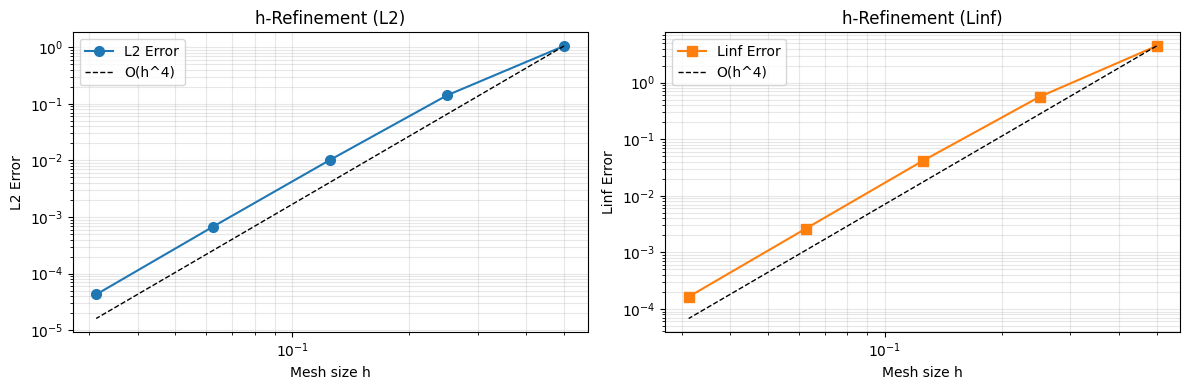

Saved plot to: /Users/user/code/Simplex-DG-solver/outputs/convergence_hrefine_pbc_square.png


In [12]:
# ============================================================================
# CELL 6: Log-Log Convergence Plots
# ============================================================================

expected_order = 4
h_plot = h_values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

ax1.loglog(h_plot, errors_l2, "o-", label="L2 Error", markersize=7)
ref_l2 = errors_l2[0] * (h_plot / h_plot[0]) ** expected_order
ax1.loglog(h_plot, ref_l2, "k--", linewidth=1.0, label=f"O(h^{expected_order})")
ax1.set_xlabel("Mesh size h")
ax1.set_ylabel("L2 Error")
ax1.set_title("h-Refinement (L2)")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2.loglog(h_plot, errors_linf, "s-", label="Linf Error", markersize=7, color="tab:orange")
ref_linf = errors_linf[0] * (h_plot / h_plot[0]) ** expected_order
ax2.loglog(h_plot, ref_linf, "k--", linewidth=1.0, label=f"O(h^{expected_order})")
ax2.set_xlabel("Mesh size h")
ax2.set_ylabel("Linf Error")
ax2.set_title("h-Refinement (Linf)")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend()

plt.tight_layout()

output_path = project_root / "outputs" / "convergence_hrefine_pbc_square.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {output_path}")